# Classifying sc vs sn droplets — usage demo

This notebook demonstrates the use of CellorNuc function in ScanpyPlus:

1. Running the classifiers — **global fit** (`CellorNucEM`);
2. **UMAP** colored by assay label and classification results.

In [4]:
%matplotlib inline
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import sys

sys.path.append('/mnt/dev0/zhouw/ScanpyPlus/')
import Scanpyplus

sc.settings.set_figure_params(dpi=90, facecolor="white")

In [5]:
sc_genes, sn_genes = Scanpyplus.LoadGeneSignatures()          # 默认 'hcka_v1'
print(f"sc_genes ({len(sc_genes)}): {sc_genes}")
print(f"sn_genes ({len(sn_genes)}): {sn_genes}")

sc_genes (10): ['EEF1A1', 'TPT1', 'FTH1', 'FTL', 'SERF2', 'ATP5F1E', 'GAPDH', 'UBA52', 'COX7C', 'MIF']
sn_genes (10): ['FTX', 'AGAP1', 'GMDS-DT', 'PARD3', 'WWOX', 'MAGI2', 'PKHD1', 'NHS', 'AC098829.1', 'DPP6']


## Classifying sc vs sn droplets on mixed data

In [10]:
## load data
adata = sc.read_h5ad('/mnt/dev1/HCKA_concat1.h5ad')
adata

AnnData object with n_obs × n_vars = 1032203 × 15786
    obs: 'batch', 'harmonized_celltype', 'Project_ID', 'author_annotation', 'scrublet_score', 'scrublet_leiden', 'cluster_scrublet_score', 'doublet_pval', 'doublet_bh_pval', 'gene_marker', 'broad_annotation', 'fine_annotation', 'leiden_R', 'author_broad_label', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden', 'consortia', 'study_pi', 'contact_email', 'batch_condition', 'default_embedding', 'sequencing_platform', 'assay_ontology_term', 'assay_ontology_term_id', 'reference_genome', 'alignment_software', 'intron_inclusion', 'ambient_count_correction', 'doublet_detection', 'sequenced_f

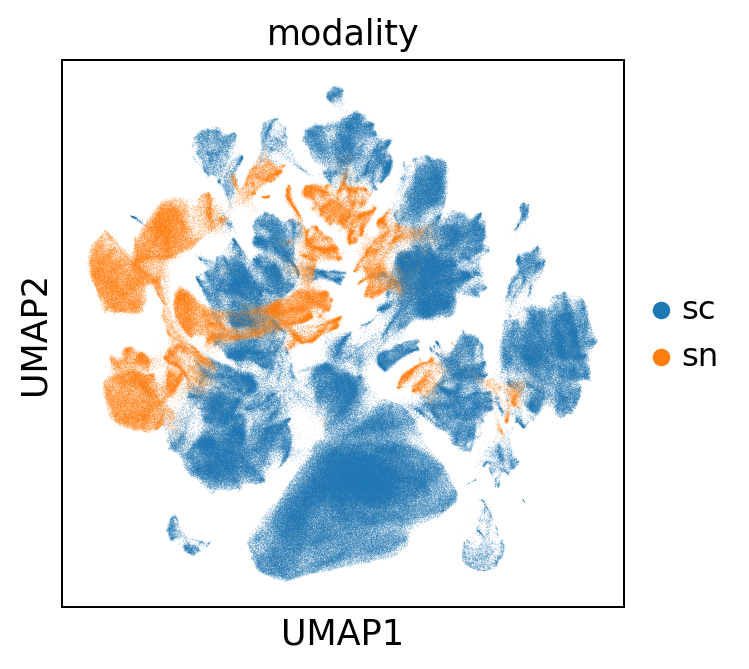

In [7]:
sc.pl.umap(adata, color=['modality'])

In [11]:
### Use raw counts to run the classifier
adata = Scanpyplus.CellorNucEM(
    adata, sc_genes, sn_genes,
    layer="counts",
    assay_col='modality',      
    gamma_hi=0.95,               
    gamma_lo=0.05,
    copy=True,
)
print(adata.obs["modality_classification"].value_counts(), "\n")
print(pd.crosstab(adata.obs["modality"], adata.obs["modality_classification"]))

modality_classification
Typical Cell (SC)         698612
Typical Nucleus (SN)      173124
Uncertain                 148406
Nucleus-like Cell (SC)     10396
Cell-like Nucleus (SN)      1665
Name: count, dtype: int64 

modality_classification  Typical Cell (SC)  Nucleus-like Cell (SC)  \
modality                                                             
sc                                  698612                   10396   
sn                                       0                       0   

modality_classification  Typical Nucleus (SN)  Cell-like Nucleus (SN)  \
modality                                                                
sc                                          0                       0   
sn                                     173124                    1665   

modality_classification  Uncertain  
modality                            
sc                          107887  
sn                           40519  


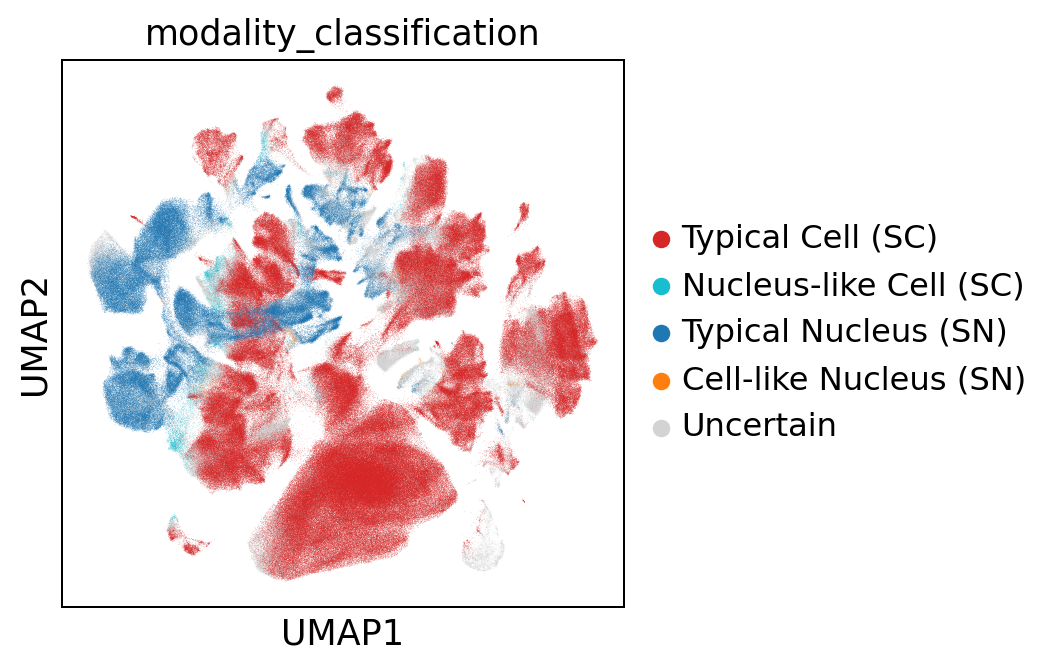

In [12]:
sc.pl.umap(adata, color=['modality_classification'])

In [13]:
### assign uncertain cells to the original modality
df = adata.obs.copy()          
truth_col = 'modality'            
pred_col  = 'modality_classification'

pred  = df[pred_col].astype(str)
truth = df[truth_col].astype(str)


merged = np.where(truth == 'sc', 'Cell (SC)', 'Nucleus (SN)').astype(object)

merged[pred.values == 'Nucleus-like Cell (SC)'] = 'Nucleus-like Cell (SC)'
merged[pred.values == 'Cell-like Nucleus (SN)'] = 'Cell-like Nucleus (SN)'

df['modality_merged'] = pd.Categorical(
    merged, categories=['Cell (SC)', 'Nucleus-like Cell (SC)',
                        'Nucleus (SN)', 'Cell-like Nucleus (SN)'])
print(df['modality_merged'].value_counts())

modality_merged
Cell (SC)                 806499
Nucleus (SN)              213643
Nucleus-like Cell (SC)     10396
Cell-like Nucleus (SN)      1665
Name: count, dtype: int64


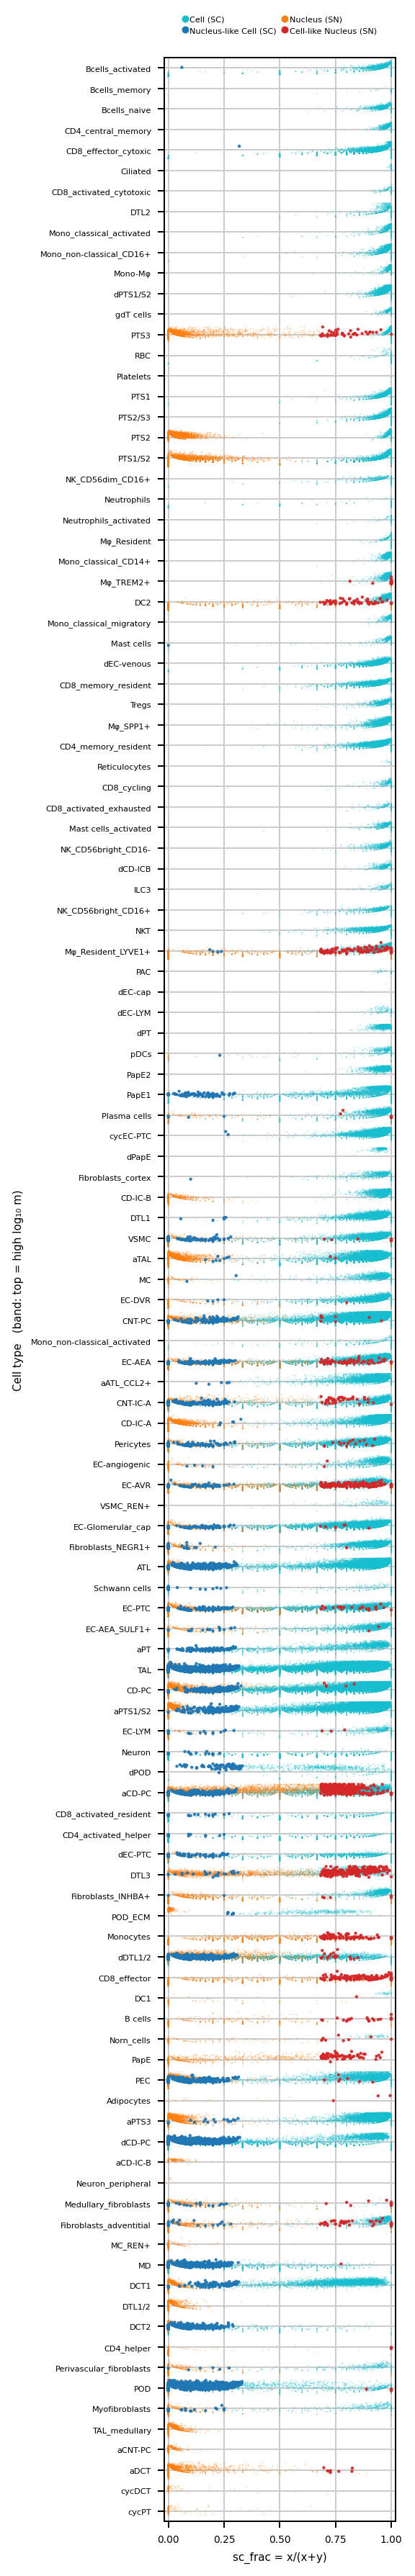

In [14]:
### curtain plot for sc vs sn distribution in each cell type
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============ Config ============
cell_type_col = 'fine_annotation'
FIG_W         = 3.4          
row_height    = 0.16         
band_spread   = 0.80

custom_palette = {
    'Cell (SC)'             : '#17becf',
    'Nucleus-like Cell (SC)': '#1f77b4',
    'Nucleus (SN)'          : '#ff7f0e',
    'Cell-like Nucleus (SN)': '#d62728',
}

# ============ data preparation ============
d = df[df[cell_type_col].notna()].copy()

vmin, vmax = d['sc_frac'].quantile([0.01, 0.99])
d['p_disp'] = d['sc_frac'].clip(vmin, vmax)

logm = np.log10(d['modality_counts'].clip(lower=1))
lo, hi = logm.quantile([0.01, 0.99])
d['m_off'] = ((logm.clip(lo, hi) - lo) / (hi - lo) - 0.5) * band_spread

order = (d.groupby(cell_type_col, observed=True)['p_disp'].median()
           .sort_values(ascending=False).index.tolist())
ypos = (d[cell_type_col].astype(str)
          .map({ct: i for i, ct in enumerate(order)}).astype(float))
d['y'] = ypos - d['m_off']        

mask_typ = d['modality_merged'].isin(['Cell (SC)', 'Nucleus (SN)'])
mask_ano = d['modality_merged'].isin(['Nucleus-like Cell (SC)', 'Cell-like Nucleus (SN)'])

# ============ plot ============
n_ct   = len(order)
fig_h  = max(3.0, n_ct * row_height + 0.8)
fig, ax = plt.subplots(figsize=(FIG_W, fig_h))

for mask, size, alpha, z in [(mask_typ, 0.6, 0.30, 2),
                             (mask_ano, 3.0, 0.95, 3)]:
    sub = d[mask]
    ax.scatter(sub['p_disp'], sub['y'],
               c=sub['modality_merged'].map(custom_palette).values,
               s=size, alpha=alpha, zorder=z, linewidths=0,
               rasterized=True)                   

ax.set_yticks(range(n_ct))
ax.set_yticklabels(order, fontsize=4.5)
ax.set_ylim(n_ct - 0.5, -0.5)
ax.set_xlim(-0.02, 1.02)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.tick_params(axis='x', labelsize=5.5)
ax.set_xlabel('sc_frac = x/(x+y)', fontsize=6)
ax.set_ylabel('Cell type   (band: top = high log₁₀ m)', fontsize=6)

legend_elems = [Line2D([0], [0], marker='o', ls='', color=c, label=l, markersize=3)
                for l, c in custom_palette.items()]
ax.legend(handles=legend_elems, loc='upper center', bbox_to_anchor=(0.5, 1.02),
          ncol=2, frameon=False, fontsize=4.5,
          handletextpad=0.3, columnspacing=0.8)

plt.tight_layout()
plt.show()

In [ ]:
# save the adata
adata.write_h5ad('/mnt/dev1/HCKA_concat1_cellornuc.h5ad')

## Classifying sc vs sn droplets on single modality data

In [ ]:
### loada a whole single cell data
adata = ad.read_h5ad('/mnt/dev0/zhouw/CellorNuc/data/Kidney_Raji_cellbender_231006Annotate.h5ad')
adata

AnnData object with n_obs × n_vars = 119727 × 31215
    obs: 'batch', 'orig.ident', 'subclass.l2', 'subclass.l1', 'dataSource', 'sampletype', 'umap1', 'umap2', 'SpecimenID', 'diseasetype', 'ClusterNumber', 'ClusterClass', 'LibraryID', 'age', 'seurat_clusters', 'gender', 'state', 'tissuetype', 'celltype', 'SpecimenID2', 'celltype_int', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent_mito', 'n_counts', 'n_genes', 'S_score', 'G2M_score', 'phase', 'leiden', 'manual_celltype_annotation', 'Predicted', 'ATL_prob', 'B_prob', 'C-TAL_prob', 'CCD-IC-A_prob', 'CCD-PC_prob', 'CNT_prob', 'CNT-IC-A_prob', 'CNT-PC_prob', 'DCT1_prob', 'DCT2_prob', 'DTL1_prob', 'DTL2_prob', 'DTL3_prob', 'EC-AEA_prob', 'EC-AVR_prob', 'EC-DVR_prob', 'EC-GC_prob', 'EC-LYM_prob', 'EC-PTC_prob', 'FIB_prob', 'IC-B_prob', 'IMCD_prob', 'M-FIB_prob', 'M-TAL_prob', 'MAC-M2_prob', 'MAST_prob', 'MC_prob', 'MD_prob', 'MDC_prob', 'MYOF_prob', 'N_prob', 'NKC/T_prob', 'OMCD-IC-A_prob', 'OMCD-PC_prob', 'PEC_prob', 'PL_prob', 'POD_p

In [16]:
### add a column of modality
adata.obs['modality'] = 'sc'

In [17]:
### run the classification
adata = Scanpyplus.CellorNucEM(
    adata, sc_genes, sn_genes,
    assay_col="modality",            
    layer="counts",
    copy=True,
    gamma_hi=0.95,
    gamma_lo=0.05,
    max_p_nuc=0.2,  # nucleus component's mean p must stay
    min_p_cell=0.8, # cell component's mean p must stay
)
print(adata.obs["modality_classification"].value_counts(), "\n")
print(pd.crosstab(adata.obs["modality"], adata.obs["modality_classification"]))

modality_classification
Typical Cell (SC)         91999
Uncertain                 24407
Nucleus-like Cell (SC)     3321
Typical Nucleus (SN)          0
Cell-like Nucleus (SN)        0
Name: count, dtype: int64 

modality_classification  Typical Cell (SC)  Nucleus-like Cell (SC)  Uncertain
modality                                                                     
sc                                   91999                    3321      24407


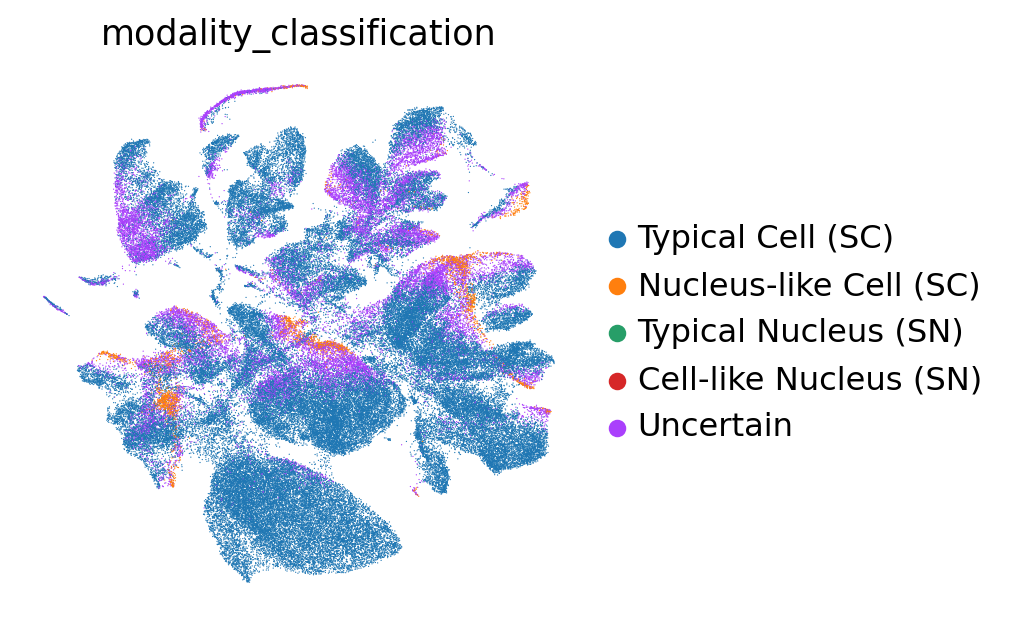

In [18]:
sc.pl.umap(adata, color=['modality_classification'], frameon=False)

In [ ]:
### save the adata
adata.write_h5ad('/mnt/dev0/zhouw/CellorNuc/data/Kidney_Raji_cellbender_231006Annotate_cellornuc.h5ad')